# Section 5: ML Ethics --> Chapter 19:  ML Ethics


---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)

**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

!pip install aif360==0.6.1
!pip install aif360[Reductions]==0.6.1
!pip install aif360[inFairness]==0.6.1
!pip install shap==0.45.0
!pip install slicer==0.0.7
!pip install lime==0.2.0.1
!pip install pdpbox==0.3.0
!pip install pandas==2.0.3
!pip install numpy==1.25.2
!pip install google.colab==0.0.1
!pip install scikit-learn==1.2.2
!pip install sklearn==1.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.1/234.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.3/239.3 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 10.1 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.

---

☑ **Import libraries**

---

In [ ]:
import numpy as np
import pandas as pd
import time  # Added time module
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Generate a sample dataset
np.random.seed(0)
num_samples = 1000


# Standard Library Imports
import time

# Third-Party Imports
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    fbeta_score, precision_score, recall_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
from pdpbox import pdp, info_plots
import matplotlib.pyplot as plt
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")


/usr/local/lib/python3.10/dist-packages/torch/_functorch/deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')


# 2. Fairness

## 2.1.4. Parity in Model Fairness

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_create_synthetic_data():  # Removed title and subtitle parameters

    data = np.random.rand(num_samples, 5)  # Example features
    sensitive_attribute = np.random.choice([0, 1], size=num_samples)  # Example sensitive attribute (binary)
    labels = np.random.choice([0, 1], size=num_samples)  # Example binary labels

    return data, sensitive_attribute, labels

# Function to Split Data
def _2_split_data(data, sensitive_attribute, labels):  # Added parameters

    # Split the data into training and testing sets
    X_train, X_test, s_train, s_test, y_train, y_test = train_test_split(
        data, sensitive_attribute, labels, test_size=0.2, random_state=42
    )

    # Create BinaryLabelDatasets for training and testing
    train_dataset = BinaryLabelDataset(
        favorable_label=1,
        unfavorable_label=0,
        df=pd.DataFrame({"label": y_train, "protected_attribute": s_train}),
        label_names=["label"],
        protected_attribute_names=["protected_attribute"],
    )

    test_dataset = BinaryLabelDataset(
        favorable_label=1,
        unfavorable_label=0,
        df=pd.DataFrame({"label": y_test, "protected_attribute": s_test}),
        label_names=["label"],
        protected_attribute_names=["protected_attribute"],
    )
    return X_train, X_test, s_train, s_test, y_train, y_test, train_dataset, test_dataset

# Function to Train Data
def _3_train_data(X_train, y_train, X_test, s_test):

    # Train a classifier (Random Forest for example)
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = clf.predict(X_test)

    # Create BinaryLabelDataset for predicted labels
    predicted_dataset = BinaryLabelDataset(
        favorable_label=1,
        unfavorable_label=0,
        df=pd.DataFrame({"label": y_pred, "protected_attribute": s_test}),
        label_names=["label"],
        protected_attribute_names=["protected_attribute"],
    )

    return predicted_dataset

# Function to Evaluate Model for Fairness
def _4_evaluate_model_for_fairness(train_dataset, test_dataset, predicted_dataset):

    # Calculate classification metrics
    privileged_group = [{test_dataset.protected_attribute_names[0]: 0}]  # Assuming 0 is the privileged value
    unprivileged_group = [{test_dataset.protected_attribute_names[0]: 1}]  # Assuming 1 is the unprivileged value

    classification_metric = ClassificationMetric(
        test_dataset,
        predicted_dataset,
        privileged_groups=privileged_group,
        unprivileged_groups=unprivileged_group,
    )

    # Calculate true positive rate for the unprivileged group
    tpr_unprivileged = classification_metric.true_positive_rate(privileged=False)

    # Calculate true positive rate for the privileged group
    tpr_privileged = classification_metric.true_positive_rate(privileged=True)

    # Calculate equalized odds difference
    equalized_odds_difference = tpr_unprivileged - tpr_privileged

    print(f"Equalized Odds Difference: {equalized_odds_difference:.4f}")

    # Calculate binary label dataset metrics
    metric = BinaryLabelDatasetMetric(test_dataset, unprivileged_groups=unprivileged_group, privileged_groups=privileged_group)

    print("\nBinary Label Dataset Metrics:")
    print(f"Disparate Impact: {metric.disparate_impact():.4f}")
    print(f"Mean Difference: {metric.mean_difference():.4f}")
    print(f"Statistical Parity Difference: {metric.statistical_parity_difference():.4f}")

# Define Main Workflow
def main():
    print_pretty_header("ML Ethics", "Fairness")  # Print Header
    data, sensitive_attribute, labels = _1_create_synthetic_data()
    X_train, X_test, s_train, s_test, y_train, y_test, train_dataset, test_dataset = _2_split_data(data, sensitive_attribute, labels)
    predicted_dataset = _3_train_data(X_train, y_train, X_test, s_test)
    _4_evaluate_model_for_fairness(train_dataset, test_dataset, predicted_dataset)

if __name__ == "__main__":
    main()


####################################################################################################

                                             ML Ethics                                              

                                              Fairness                                              

####################################################################################################

Equalized Odds Difference: 0.1342

Binary Label Dataset Metrics:
Disparate Impact: 1.1639
Mean Difference: 0.0785
Statistical Parity Difference: 0.0785


## 2.3.4. Parity in Model Transparency

####################################################################################################

                                    Visualize Feature Importance                                    

                                      Decision Tree Classifier                                      

####################################################################################################



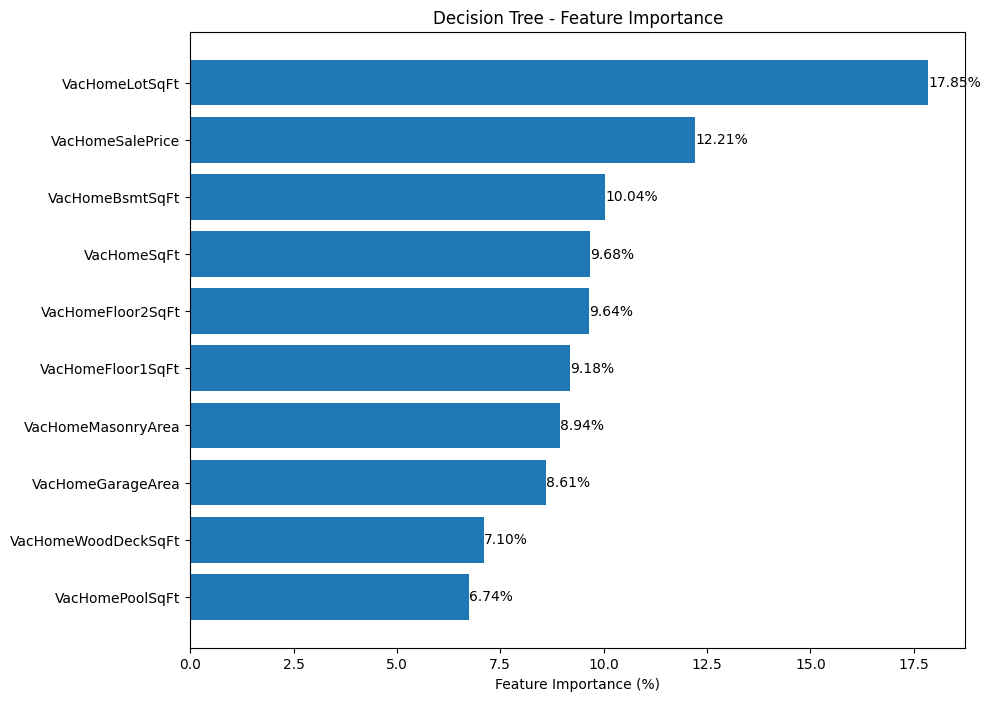

Error: Unable to generate SHAP values.


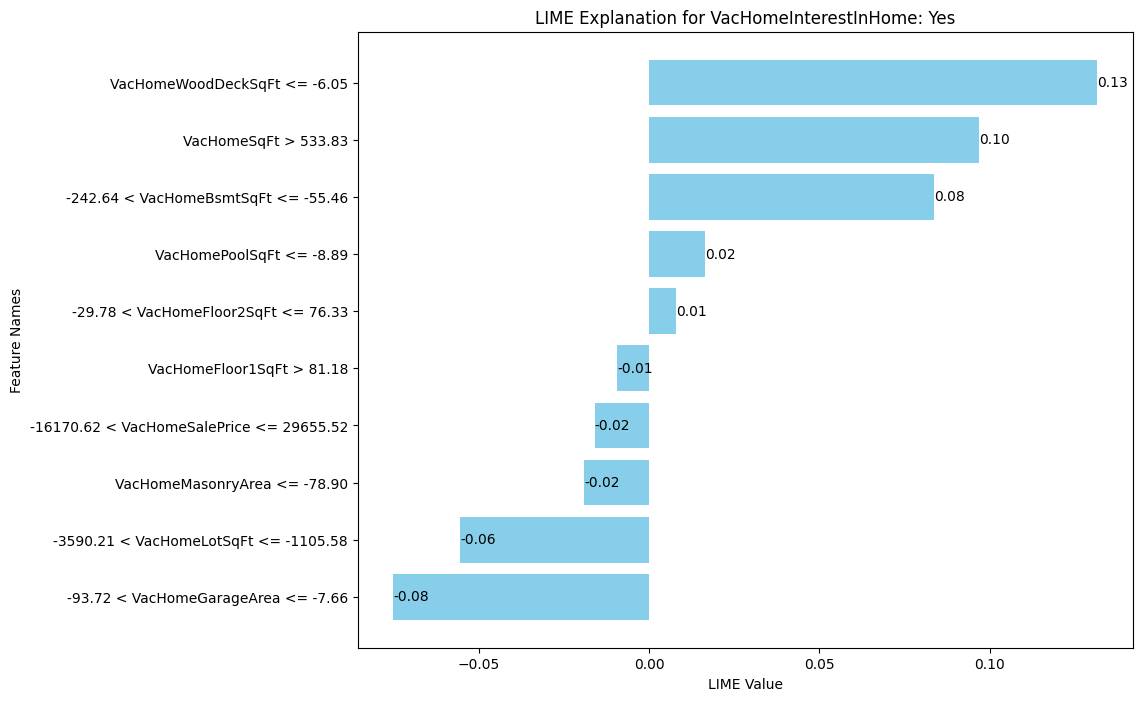

Feature: -93.72 < VacHomeGarageArea <= -7.66, LIME Value: -0.07514492887628176
Feature: -3590.21 < VacHomeLotSqFt <= -1105.58, LIME Value: -0.0554025412315133
Feature: VacHomeMasonryArea <= -78.90, LIME Value: -0.01901865401322388
Feature: -16170.62 < VacHomeSalePrice <= 29655.52, LIME Value: -0.01589425342967209
Feature: VacHomeFloor1SqFt > 81.18, LIME Value: -0.009295400067826275
Feature: -29.78 < VacHomeFloor2SqFt <= 76.33, LIME Value: 0.008011781429145918
Feature: VacHomePoolSqFt <= -8.89, LIME Value: 0.016392312792831577
Feature: -242.64 < VacHomeBsmtSqFt <= -55.46, LIME Value: 0.08369053814699771
Feature: VacHomeSqFt > 533.83, LIME Value: 0.09691730847714208
Feature: VacHomeWoodDeckSqFt <= -6.05, LIME Value: 0.13161138969261635


In [ ]:


# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():

    target_column = 'VacHomeInterestInHome'

    binary_evaluation_columns = ['Data', 'Algorithm', 'Recall', 'Precision', 'Accuracy', 'Balanced Accuracy',
                          'False Positive Rate', 'False Negative Rate', 'True Negative Rate',
                          'Negative Predictive Value', 'False Discovery Rate', 'Duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt', 'VacHomeSalePrice', 'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality','VacHomeReviewDate'
    ]
    return binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column

# Function to Split Data
def _3_split_data(df_rawdata):

    target_column = 'VacHomeInterestInHome'
    # Calculate the number of rows needed for the training set (50%)
    training_size = len(df_rawdata) // 2

    # Slice the data to create the training and test sets
    df_train_data = df_rawdata.iloc[:training_size]
    df_test_data = df_rawdata.iloc[training_size:]

    # Map 'N' to 0 and 'Y' to 1 for the target variable
    df_train_data[target_column] = df_train_data[target_column].map({'N': 0, 'Y': 1})
    df_test_data[target_column] = df_test_data[target_column].map({'N': 0, 'Y': 1})

    y_split_train = df_train_data[target_column].values
    X_split_train = df_train_data.drop(columns=target_column)
    y_split_test = df_test_data[target_column].values
    X_split_test = df_test_data.drop(columns=target_column)
    return X_split_train, y_split_train, X_split_test, y_split_test

# Functions for Data Processing and Encoding
def _4_preprocess_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):

    # Impute NaN values
    for col in continuous_columns:
        train_data[col].fillna(train_data[col].mean(), inplace=True)
        test_data[col].fillna(train_data[col].mean(), inplace=True)

    for col in nominal_columns:
        train_data[col].fillna("Unknown", inplace=True)
        test_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        train_data[col].fillna(15, inplace=True)
        test_data[col] = ['N' if label == '0' else label for label in test_data[col]]
        test_data[col].fillna(15, inplace=True)

    train_preprocessed_data = train_data.drop(columns=ignore_columns)
    test_preprocessed_data = test_data.drop(columns=ignore_columns)
    return train_preprocessed_data, test_preprocessed_data

# Function to Encode Data
def _5_encode_data(train_data, test_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    label_encoder = LabelEncoder()
    for col in ordinal_columns:
        train_data[col] = label_encoder.fit_transform(train_data[col].astype(str))
        test_data[col] = label_encoder.transform(test_data[col].astype(str))

    for col in nominal_columns:
        if col in train_data.columns and col in test_data.columns:
            train_data[col] = label_encoder.fit_transform(train_data[col])
            test_data[col] = label_encoder.transform(test_data[col])

    train_encoded_data = pd.get_dummies(train_data, columns=nominal_columns, drop_first=True)
    test_encoded_data = pd.get_dummies(test_data, columns=nominal_columns, drop_first=True)

    return train_encoded_data, test_encoded_data

def _6_check_for_imbalanced_data(y_split_train):
    df_train_data = pd.DataFrame({'VacHomeInterestInHome': y_split_train})  # Convert the NumPy array to a DataFrame
    df_train_data['VacHomeInterestInHome'] = df_train_data['VacHomeInterestInHome'].replace({1: 'Interested', 0: 'Not Interested'})

    # Rest of your code
    # df_train_data.value_counts().plot(kind='barh')
    # plt.show()
    return


# Function to PCA
def _7_run_pca(X_train_encoded, X_test_encoded, original_feature_names):
    # Define the number of components you want to keep
    n_components = 10  # You can choose a suitable number

    # Initialize PCA and fit on your data
    pca = PCA(n_components=n_components)

    X_train_pca = pca.fit_transform(X_train_encoded)  # Fit and transform training data
    X_test_pca = pca.fit_transform(X_test_encoded)  # Transform test data using the same PCA model

    # Get the real feature names after PCA
    pca_feature_names = [f"{original_feature_names[j]}" for i, j in zip(range(n_components), pca.components_.argsort()[:, ::-1][:, :n_components].flatten())]

    return X_train_pca, X_test_pca, pca_feature_names

# Function to Append Binary Result DataFrame
def _9_evaluate_binary_models(binary_result_df, data, clf_name, y_pred, y_true, duration):

    accuracy_score_val = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
    recall =recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        false_positive_rate = fp / (fp + tn)
        false_negative_rate = fn / (tp + fn)
        true_negative_rate = tn / (tn + fp)
        negative_predictive_value = tn / (tn + fn)
    else:
        tn, fp, fn, tp = 0, 0, 0, 0
        false_positive_rate, false_negative_rate, true_negative_rate, negative_predictive_value= 0, 0, 0, 0

    if (tp + fp) == 0:
        false_discovery_rate = 0.0
    else:
        false_discovery_rate = fp / (tp + fp)

    new_row = {
        'Data': data,
        'Algorithm': clf_name,
        'Recall': recall,
        'Precision': precision,
        'Accuracy': accuracy_score_val,
        'Balanced Accuracy': balanced_accuracy,
        'False Positive Rate': false_positive_rate,
        'False Negative Rate': false_negative_rate,
        'True Negative Rate': true_negative_rate,
        'Negative Predictive Value': negative_predictive_value,
        'False Discovery Rate': false_discovery_rate,
        'Duration': duration
    }
    # Append the new row to the DataFrame
    binary_result_df = pd.concat([binary_result_df, pd.DataFrame([new_row])], ignore_index=True)

    return binary_result_df

# Define Function to Train Model
def _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_true, binary_result_df, clf_name , clf):

    t0 = time.time()

    clf.fit(X_train_pca, y_split_train)
    y_pred = clf.predict(X_test_pca)
    y_pred_train = clf.predict(X_train_pca)
    t1 = time.time()
    duration = round(t1 - t0, ndigits=4)

    binary_result_df = _9_evaluate_binary_models(binary_result_df, "Training Data", clf_name, y_pred_train, y_split_train, duration)
    binary_result_df = _9_evaluate_binary_models(binary_result_df, "Test Data", clf_name, y_pred, y_true, duration)

    return binary_result_df

def _10_visualize_feature_importance(importance, names, model_type):
    # Create arrays from feature importance and feature names
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    # Normalize feature importance to sum up to 100
    normalized_importance = (feature_importance / np.sum(feature_importance)) * 100

    # Create a DataFrame using a Dictionary
    data = {'feature_names': feature_names, 'normalized_importance': normalized_importance}
    fi_df = pd.DataFrame(data)

    # Reverse sort the DataFrame in descending order by feature importance
    fi_df.sort_values(by=['normalized_importance'], ascending=True, inplace=True)

    # Print pretty header
    print_pretty_header("Visualize Feature Importance", "Decision Tree Classifier")

    # Create a bar plot with feature values and importance levels
    plt.figure(figsize=(10, 8))
    bars = plt.barh(fi_df['feature_names'], fi_df['normalized_importance'])

    for bar, importance_value in zip(bars, fi_df['normalized_importance']):
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f"{importance_value:.2f}%", va='center', ha='left')

    plt.title(model_type + ' - Feature Importance')
    plt.xlabel('Feature Importance (%)')
    plt.show()

def _11_generate_shap_values(clf, X_train_pca, pca_feature_names):
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_train_pca)
    class_names = ['Not Interested', 'Interested']

    # Convert shap_values to numpy array if it's a list
    if isinstance(shap_values, list):
        shap_values = np.array(shap_values)

        # If there are multiple classes, consider only the SHAP values for the positive class
        if shap_values.ndim == 3 and shap_values.shape[0] == 2:
            shap_values = shap_values[1]  # Select SHAP values for the positive class

        # Calculate mean absolute SHAP values
        mean_shap_values = np.abs(shap_values).mean(axis=0)

        # Get feature importance order
        sorted_indices = np.argsort(mean_shap_values)[::1]  # Sort indices in descending order

        # Flatten the sorted indices array
        sorted_indices = np.ravel(sorted_indices)

        # Get feature names in the correct order
        sorted_feature_names = [pca_feature_names[i] for i in sorted_indices]

        # Get mean SHAP values in the correct order
        sorted_mean_shap_values = mean_shap_values[sorted_indices]

        # Plot the SHAP summary plot
        plt.figure(figsize=(10, 8))
        plt.barh(sorted_feature_names, sorted_mean_shap_values, color='skyblue')
        plt.xlabel('Mean |SHAP| Value')
        plt.ylabel('Feature')
        plt.title('SHAP Feature Importance')
        plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

        # Print SHAP values on the plot
        for i, (feature, shap_value) in enumerate(zip(sorted_feature_names, sorted_mean_shap_values)):
            plt.text(shap_value, i, f"{shap_value:.2f}", ha='left', va='center')

        plt.tight_layout()  # Adjust layout to prevent overlap
        plt.show()

    else:
        print("Error: Unable to generate SHAP values.")

    return shap_values

# Modify function to generate LIME explanations
def _12_generate_lime_explanations(clf, X_train_pca, pca_feature_names):
    # Initialize LimeTabularExplainer with original feature names
    explainer = LimeTabularExplainer(X_train_pca, feature_names=pca_feature_names, mode="classification")

    # Select a sample instance for explanation
    instance_idx = 0
    instance = X_train_pca[instance_idx]

    # Generate LIME explanation for the selected instance
    lime_exp = explainer.explain_instance(instance, clf.predict_proba, num_features=len(pca_feature_names))

    # Sort LIME values in descending order
    lime_values = sorted(lime_exp.as_list(), key=lambda x: x[1], reverse=False)
    feature_names = [x[0] for x in lime_values]
    lime_scores = [x[1] for x in lime_values]

    # Plot the explanation
    plt.figure(figsize=(10, 8))
    bars = plt.barh(feature_names, lime_scores, color='skyblue')
    plt.xlabel('LIME Value')
    plt.ylabel('Feature Names')
    plt.title('LIME Explanation for ' + 'VacHomeInterestInHome: Yes')  # Update the title with the new class name

    # Add annotations for LIME values
    for bar, lime_value in zip(bars, lime_scores):
        plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                 f"{lime_value:.2f}", va='center', ha='left')

    plt.show()
    return feature_names, lime_scores

def main():
    # Step 0. Start the timer
    start_time = time.time()

    # Step 1. Get Training Data
    df_rawdata = _1_get_data()

    # Step 2. Define Variables
    binary_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns, target_column = _2_define_variables()
    binary_result_df = pd.DataFrame(columns=binary_evaluation_columns)

    # Step 3. Split data
    X_split_train, y_split_train, X_split_test, y_split_test = _3_split_data(df_rawdata)

    # Step 4. Preprocess data
    train_preprocessed_data, test_preprocessed_data = _4_preprocess_data(X_split_train, X_split_test, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Encode data
    X_train_encoded, X_test_encoded = _5_encode_data(train_preprocessed_data, test_preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 6. Check for Imbalanced Data
    _6_check_for_imbalanced_data(y_split_train)

    # Step 7. Run PCA for dimensionality reduction
    X_train_pca, X_test_pca, pca_feature_names = _7_run_pca(X_train_encoded, X_test_encoded, X_train_encoded.columns)

    # Step 8. Train and evaluate the model
    clf_name = 'DecisionTreeClassifier'
    classifier = DecisionTreeClassifier()
    binary_result_df = _8_train_binary_model(X_train_pca, y_split_train, X_test_pca, y_split_test, binary_result_df, clf_name , classifier)

    # Step 9. Obtain and print feature importance
    feature_importance = classifier.feature_importances_

    # Step 10. Visualize feature importance
    _10_visualize_feature_importance(feature_importance, pca_feature_names,'Decision Tree' )

    # Step 11. Generate SHAP values
    shap_values = _11_generate_shap_values(classifier, X_train_pca, pca_feature_names)

    # Step 12. Generate LIME explanations
    lime_feature_names, lime_scores = _12_generate_lime_explanations(classifier, X_train_pca, pca_feature_names)

    # Print feature names and LIME scores
    for feature, score in zip(lime_feature_names, lime_scores):
        print(f"Feature: {feature}, LIME Value: {score}")

    return binary_result_df

if __name__ == "__main__":
    binary_result_df = main()  # Call main() and store the result in binary_result_df
    binary_result_df


------------- End of **S5_Ch19_ML_Ethics Chapter Code** for **Applied Machine Learning for Data Science Practitioners** ------------ Vidya Subramanian ------------------